# Traffic Volume Prediction using Machine Learning

This project predicts hourly traffic volume using time-based features and lag variables.  
Models implemented: Linear Regression and Random Forest..

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## 1.Loading data
The Metro Interstate Traffic dataset is loaded using pandas. 
This dataset contains hourly traffic volume along with weather and time information.

In [170]:
df=pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")
df.head()
df.shape

(48204, 9)

In [171]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


## 2.Data exploration
Initial exploration is performed to understand traffic patterns across different hours and days of the week. 
Visualization helps identify daily traffic trends and rush-hour behavior.

In [172]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df[['date_time','hour']].head()


,date_time,hour
0,2012-10-02 09:00:00,9
1,2012-10-02 10:00:00,10
2,2012-10-02 11:00:00,11
3,2012-10-02 12:00:00,12
4,2012-10-02 13:00:00,13


In [173]:
hourly_avg = df.groupby('hour')['traffic_volume'].mean()
hourly_avg

hour
0      834.781051
1      516.449000
2      388.353640
3      371.090864
4      702.551889
5     2094.573437
6     4140.503594
7     4740.181337
8     4587.497115
9     4385.277502
10    4184.665544
11    4465.877561
12    4718.293095
13    4714.940682
14    4931.888776
15    5240.524302
16    5663.756539
17    5310.076048
18    4263.718530
19    3276.394187
20    2834.667509
21    2668.940464
22    2199.405717
23    1469.135294
Name: traffic_volume, dtype: float64

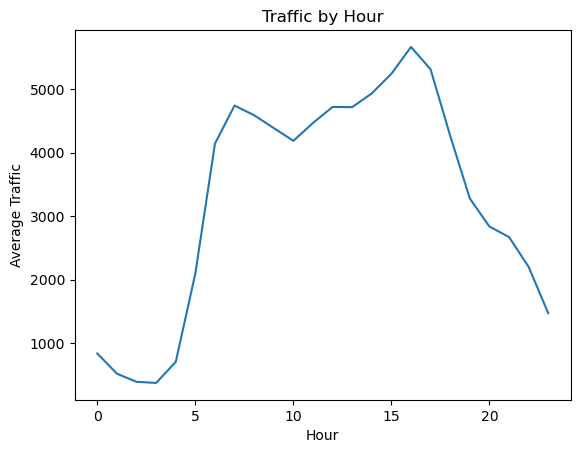

In [174]:
plt.figure()
hourly_avg.plot()
plt.xlabel("Hour")
plt.ylabel("Average Traffic")
plt.title("Traffic by Hour")
plt.show()

In [175]:
df['day_of_week'] = df['date_time'].dt.dayofweek
daily_avg = df.groupby('day_of_week')['traffic_volume'].mean()
daily_avg

day_of_week
0    3309.387161
1    3488.555799
2    3583.196681
3    3637.899663
4    3656.358836
5    2773.638120
6    2368.588329
Name: traffic_volume, dtype: float64

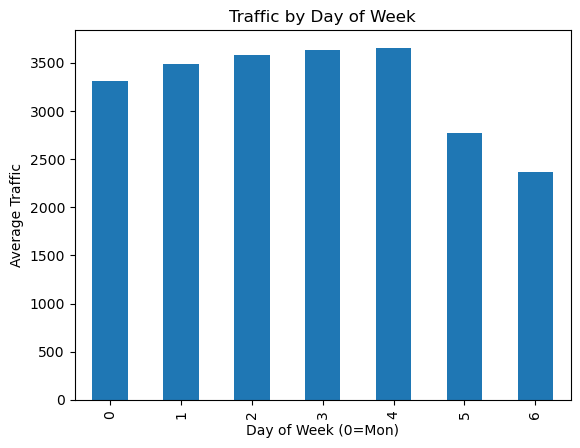

In [176]:
plt.figure()
daily_avg.plot(kind='bar')
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Traffic")
plt.title("Traffic by Day of Week")
plt.show()

## 3.Feature engineering
A lag feature (lag_1) is added to capture the previous hour's traffic volume, which is useful for time-series prediction.

In [177]:
df = df.sort_values('date_time')
df['lag_1'] = df['traffic_volume'].shift(1)
df['lag_2'] = df['traffic_volume'].shift(2)
df['lag_6'] = df['traffic_volume'].shift(6)
df['lag_12'] = df['traffic_volume'].shift(12)
df['lag_24'] = df['traffic_volume'].shift(24)


In [178]:
df = df.dropna(subset=["lag_1","lag_2","lag_6","lag_12","lag_24"])
df.shape

(48180, 16)

In [179]:
X = df[["hour","day_of_week","lag_1","lag_2","lag_6","lag_12","lag_24"]]
y = df["traffic_volume"]
print(X.head())
print(y.head())
print(X.shape)
print(y.shape)

    hour  day_of_week   lag_1   lag_2   lag_6  lag_12  lag_24
24    12            2  5471.0  6511.0   367.0  2361.0  5545.0
25    13            2  5097.0  5471.0   814.0  1529.0  4516.0
26    14            2  4887.0  5097.0  2718.0   963.0  4767.0
27    15            2  5337.0  4887.0  5673.0   506.0  5026.0
28    16            2  5692.0  5337.0  6511.0   321.0  4918.0
24    5097
25    4887
26    5337
27    5692
28    6137
Name: traffic_volume, dtype: int64
(48180, 7)
(48180,)


## 4.Model training
A Linear Regression model is trained using the engineered features (hour, day_of_week, lag_1).
The dataset is split into training and testing sets to evaluate model performance.

In [180]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,shuffle=False
)
print(X_train.shape)
print(X_test.shape)

(38544, 7)
(9636, 7)


In [181]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [182]:
rf = RandomForestRegressor(n_estimators=100, random_state=50)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

## 5. Model Evaluation
Model performance is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to measure prediction accuracy.

In [183]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Linear Regression MAE:", mae)
print("Random Forest MAE:", rf_mae)
print("Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression MAE: 437.20278613096053
Random Forest MAE: 156.38098277293483
Linear Regression RMSE: 585.7837088656187
Random Forest RMSE: 251.2188860186165


## 6. Prediction Visualization
Predicted traffic values are compared with actual traffic values to visually assess how well the model captures traffic patterns.

In [184]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

In [185]:
comparison_rf = pd.DataFrame({
    "Actual": y_test,
    "Predicted_RF": rf_pred
})

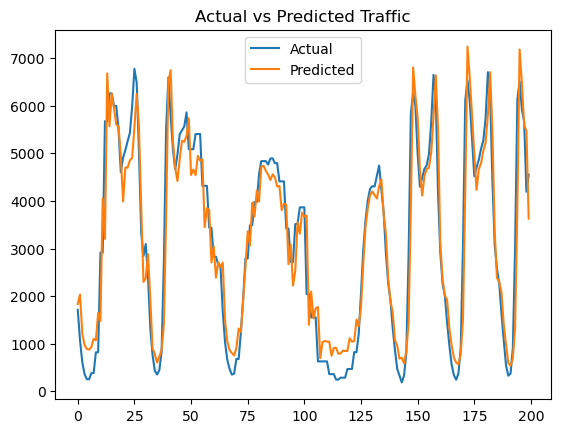

In [186]:
plt.figure()
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Traffic")
plt.show()

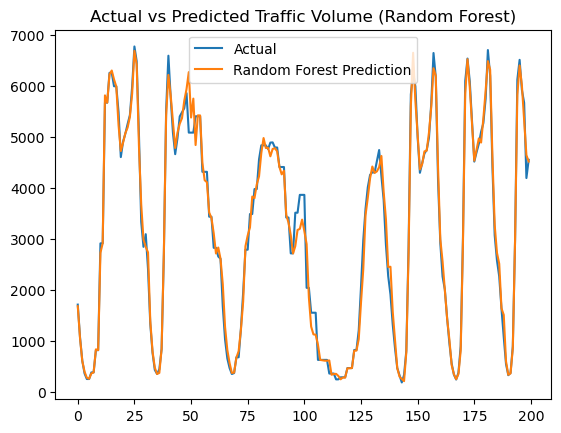

In [187]:
plt.figure()
plt.plot(comparison_rf["Actual"].values[:200], label="Actual")
plt.plot(comparison_rf["Predicted_RF"].values[:200], label="Random Forest Prediction")
plt.legend()
plt.title("Actual vs Predicted Traffic Volume (Random Forest)")
plt.show()